# 房价预测模型评估

本 Notebook 实现了两种线性回归模型的训练、评估和对比：
- **OLS (Ordinary Least Squares)** - 普通最小二乘法（独立训练）
- **Ridge Regression** - 岭回归（L2正则化，多个alpha值）

## 评估指标
- **6折交叉验证 MAE**
- **In-sample 性能** (MAE, RMSE, R²)
- **Out-of-sample 性能** (MAE, RMSE, R²)


## 1. 导入库和数据


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 库导入成功")


✓ 库导入成功


In [2]:
pd.set_option('display.max_columns', None)   # 显示所有列
pd.set_option('display.max_rows', 100)       # 最多显示100行（可自行调整）
pd.set_option('display.width', 200)          # 控制输出宽度，防止换行
pd.set_option('display.max_colwidth', 50)    # 控制每列的最大字符宽度（默认50，可改为None）

In [3]:
price_train = pd.read_csv(r"C:\Users\lenovo\Desktop\Data\train_price_clean_v10.csv")
price_test = pd.read_csv(r"C:\Users\lenovo\Desktop\Data\test_price_clean_v10.csv")

In [4]:
ori_train = pd.read_csv(r'C:\Users\lenovo\Desktop\Data\ruc_Class25Q2_train_price.csv')
ori_test = pd.read_csv(r'C:\Users\lenovo\Desktop\Data\ruc_Class25Q2_test_price.csv')

## 2.Data Processing

In [5]:
# ⚡ 向量化优化版 - 处理交易时间列（速度快100倍以上！）
from datetime import datetime

# 向量化计算月份差
trade_dates = pd.to_datetime(ori_train['交易时间'], errors='coerce')
ref_date = pd.to_datetime('2025-10-01')
ori_train['交易距今月数'] = (ref_date.year - trade_dates.dt.year) * 12 + (ref_date.month - trade_dates.dt.month)

# 测试集
trade_dates_test = pd.to_datetime(ori_test['交易时间'], errors='coerce')
ori_test['交易距今月数'] = (ref_date.year - trade_dates_test.dt.year) * 12 + (ref_date.month - trade_dates_test.dt.month)

print("✓ 处理完成！")
print("\n训练集 - 交易距今月数统计：")
print(ori_train['交易距今月数'].describe())
print(f"\n示例数据：")
print(ori_train[['交易时间', '交易距今月数']].head(10))


✓ 处理完成！

训练集 - 交易距今月数统计：
count    103871.000000
mean         18.370007
std           9.052116
min           9.000000
25%          12.000000
50%          16.000000
75%          22.000000
max          84.000000
Name: 交易距今月数, dtype: float64

示例数据：
         交易时间  交易距今月数
0  2021-03-29      55
1  2020-10-29      60
2  2020-11-24      59
3  2023-03-10      31
4  2019-12-12      70
5  2022-01-05      45
6  2021-04-04      54
7  2020-02-05      68
8  2020-03-04      67
9  2021-07-02      51


In [6]:
price_train = price_train.drop(columns = ['交易距今年数'])
price_test = price_test.drop(columns = ['交易距今年数'])

In [7]:
price_train['交易距今月数'] = ori_train['交易距今月数']
price_test['交易距今月数'] = ori_test['交易距今月数']

In [8]:
# ==========================================================
# Load Cleaned Data
# ==========================================================
print("Loading cleaned data...")
df_train_full = price_train.copy()
df_test_predict = price_test.copy()

Loading cleaned data...


In [9]:
X_train = df_train_full.drop(columns = ['Price'])
y_train = df_train_full['Price']

In [10]:
# 移除异常值（使用 IQR 方法）
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (y_train >= lower_bound) & (y_train <= upper_bound)

X_tr = X_train[outlier_mask]
y_tr = y_train[outlier_mask]

print(f"异常值移除统计:")
print(f"  原始训练集样本数: {len(y_train):,}")
print(f"  移除异常值后样本数: {len(y_tr):,}")
print(f"  移除的样本数: {len(y_train) - len(y_tr):,}")
print(f"  移除比例: {(1 - len(y_tr)/len(y_train))*100:.2f}%")
print(f"\n✓ 异常值移除完成")


异常值移除统计:
  原始训练集样本数: 103,871
  移除异常值后样本数: 96,048
  移除的样本数: 7,823
  移除比例: 7.53%

✓ 异常值移除完成


In [11]:
df_train_full = df_train_full[outlier_mask]

## 3 Feature Engineering

### 3.1 利用留一法防止数据泄露

In [12]:
def loo_target_encoding(df, feature, target):
    """
    计算留一法 (LOO) 目标编码。
    
    Args:
        df (pd.DataFrame): 训练数据集。
        feature (str): 要编码的类别特征列名 (如 'cluster_id')。
        target (str): 目标变量列名 (如 'Price')。
        
    Returns:
        pd.DataFrame: 包含 LOO 编码列的新DataFrame。
    """
    # 1. 计算每个类别的 Sum 和 Count
    agg_df = df.groupby(feature)[target].agg(['sum', 'count']).reset_index()
    agg_df.columns = [feature, f'{feature}_Sum', f'{feature}_Count']
    
    # 2. 合并 Sum 和 Count 到主DataFrame
    df = df.merge(agg_df, on=feature, how='left')
    
    # 3. 计算 LOO 均值：(总和 - 自身价格) / (总计数 - 1)
    # np.maximum(..., 0.001) 用于防止除以0（即 Count=1 的情况）
    df[f'{feature}_LOO_Mean'] = (df[f'{feature}_Sum'] - df[target]) / \
                                 (df[f'{feature}_Count'] - 1).replace(0, np.nan) 
    
    # 4. 平滑处理（针对 Count=1 的稀疏情况）
    # 当 Count=1 时，LOO均值为 NaN。我们用全局均值来填充。
    global_mean = df[target].mean()
    df[f'{feature}_LOO_Mean'] = df[f'{feature}_LOO_Mean'].fillna(global_mean)
    
    # 清理中间列
    df = df.drop(columns=[f'{feature}_Sum', f'{feature}_Count'])
    
    return df

In [13]:
# ==========================================================
# Feature Engineering Steps (applied to both train and test)
# ==========================================================
print("\nPerforming feature engineering...")

def engineer_features(df, train_stats=None):
    """Applies feature transformations and creates interactions."""
    df_eng = df.copy()

    # --- 1. Target Variable (Log Transform) ---
    # Ensure Log_Price exists or create it
    if 'Price' in df_eng.columns and 'Log_Price' not in df_eng.columns:
        df_eng['Log_Price'] = np.log1p(df_eng['Price'])

    # --- 2. Numerical Transformations ---
    # Log transform relevant features (using log1p for stability)
    for col in ['建筑面积', '套内面积', '房屋总数', '楼栋总数', '停车位',
                '区域_均价编码', '板块_均价编码']:
        if col in df_eng.columns:
            # Handle potential zeros or negative values before log
            df_eng[f'{col}_log'] = np.log1p(df_eng[col].clip(lower=0))

    # Ensure derived features from cleaning exist or create them
    if 'Log_面积' not in df_eng.columns and '套内面积' in df_eng.columns:
         df_eng['Log_面积'] = np.log1p(df_eng['套内面积'])
    if '房龄' not in df_eng.columns and '年份' in df_eng.columns: # Estimate房龄 if missing
        current_year = 2025 # Or get dynamically
        df_eng['房龄'] = current_year - df_eng['年份']
        df_eng['房龄'] = df_eng['房龄'].clip(lower=0) # Age cannot be negative
    if '房龄_倒数' not in df_eng.columns and '房龄' in df_eng.columns:
         df_eng['房龄_倒数'] = 1 / (df_eng['房龄'] + 1)
    if '楼层比例' not in df_eng.columns and '当前楼层' in df_eng.columns and '总楼层' in df_eng.columns:
         # Avoid division by zero or NaN
         df_eng['楼层比例'] = (df_eng['当前楼层'] / df_eng['总楼层'].replace(0, np.nan)).fillna(0.5) # fillna with mid-value
    if '当前楼层_sq' not in df_eng.columns and '当前楼层' in df_eng.columns:
         df_eng['当前楼层_sq'] = df_eng['当前楼层'] ** 2
    if '楼层比例_sq' not in df_eng.columns and '楼层比例' in df_eng.columns:
         df_eng['楼层比例_sq'] = df_eng['楼层比例'] ** 2

    # --- 3. Interaction Terms ---
    # Ensure base columns exist before creating interactions
    if 'Log_面积' in df_eng.columns and '装修情况_精装' in df_eng.columns:
        df_eng['面积_精装_交互'] = df_eng['Log_面积'] * df_eng['装修情况_精装']
    if '当前楼层' in df_eng.columns and '配备电梯_有' in df_eng.columns:
        df_eng['高层_电梯_交互'] = df_eng['当前楼层'] * df_eng['配备电梯_有']

    # Area * Ring Interactions (using the most granular ring columns available)
    ring_cols = [col for col in df_eng.columns if col.startswith('环线_')] # Adjust prefix if needed
    if 'Log_面积' in df_eng.columns:
        for ring_col in ring_cols:
            df_eng[f'面积_{ring_col}_交互'] = df_eng['Log_面积'] * df_eng[ring_col]

    # New Interactions
    if '房龄_倒数' in df_eng.columns and '物业类别_别墅' in df_eng.columns:
         df_eng['房龄_别墅_交互'] = df_eng['房龄_倒数'] * df_eng['物业类别_别墅']
    if '卧室数' in df_eng.columns and 'Log_面积' in df_eng.columns:
         df_eng['卧室_面积_交互'] = df_eng['卧室数'] * df_eng['Log_面积']
    # Optional: Log Area Squared
    # if 'Log_面积' in df_eng.columns:
    #      df_eng['Log_面积_sq'] = df_eng['Log_面积'] ** 2

    # --- 4. LOO Feature Placeholder (will be calculated dynamically in CV) ---
    df_eng['log_cluster_price_LOO'] = 0.0 # Placeholder

    return df_eng

# Apply feature engineering to both sets initially
df_train = engineer_features(df_train_full)
df_test = engineer_features(df_test_predict) # No train_stats needed yet

print("Feature engineering steps applied.")



Performing feature engineering...
Feature engineering steps applied.


In [45]:
# ==========================================================
# Define Feature Sets for Scaling and Passthrough
# ==========================================================

# A. Continuous numerical features (to be scaled)
numerical_features = [
    'Log_面积', '房龄_倒数', '当前楼层', '当前楼层_sq', '楼层比例', '楼层比例_sq',
    '室', '厅', '卫', '房屋总数', '楼栋总数','总楼层',
    '绿化率', '容积率', '物业费', '梯户比', '卧室数', '客厅数', '厨房数', '卫生间数',
    '配套设施数量', '人均面积', '交易距今年数', # Assuming these exist from cleaning
    '停车位', '停车费用', '燃气费', # Assuming these exist
    # Log-transformed scale features
    '房屋总数_log', '楼栋总数_log', '停车位_log',
    # Log-transformed target encoded features
     '交易距今月数', '客户反馈'
]
# Add LOO placeholder (will be scaled)
numerical_features.append('log_cluster_price_LOO')

# B. Interaction features (to be scaled)
interaction_features = [col for col in df_train.columns if '_交互' in col]

# C. Binary features (0/1 - passthrough)
# Identify binary columns automatically (excluding known numerical/target/ID/LOO placeholders)
features_to_exclude = ['Price', 'Log_Price', 'ID', 'cluster_id', 'cluster_mean_price', # IDs & Targets
                       '建筑面积', '套内面积', '年份', '房龄', # Original numericals
                       '区域_均价编码', '板块_均价编码', '区域_均价编码_log','板块_均价编码_log', # Original target encoded
                       'cluster_id_LOO_Mean' # Intermediate LOO step
                       ] + numerical_features + interaction_features # Exclude already categorized

binary_features = [col for col in df_train.columns
                   if df_train[col].dropna().nunique() <= 2 # Check for 0/1 or similar
                   and col not in features_to_exclude
                   and not pd.api.types.is_numeric_dtype(df_train[col].dtype) == False # Ensure it's treated numerically if 0/1
                   ]

# Refine binary_features: Ensure only actual 0/1 columns are included
# This is heuristic; adjust if needed based on actual column values
true_binary = []
for col in binary_features:
    unique_vals = df_train[col].dropna().unique()
    if len(unique_vals) <= 2 and all(v in [0, 1, 0.0, 1.0] for v in unique_vals):
        true_binary.append(col)
binary_features = true_binary


# Combine features for scaling
scaling_features = [col for col in numerical_features + interaction_features if col in df_train.columns]
# Ensure final feature list for model use
features_to_use = scaling_features + binary_features + ['板块_均价编码', '区域_均价编码']

print(f"\nIdentified {len(scaling_features)} features for scaling.")
print(f"Identified {len(binary_features)} binary features for passthrough.")
# print("\nScaling Features:", scaling_features)
# print("\nBinary Features:", binary_features)


Identified 38 features for scaling.
Identified 133 binary features for passthrough.


In [46]:
df_train['Price_log'] = np.log(df_train['Price'])

### 3.2 筛选特征

In [17]:
import sys
sys.path.append("C:/Users\lenovo\Desktop\code/")
import FeatureEngineering_rent_v2
import importlib
importlib.reload(FeatureEngineering_rent_v2)
from FeatureEngineering_rent_v2 import *

selected_features, selection_info = feature_selection(
    df_train[features_to_use + ['Price_log']],
    target='Price_log',
    n_features=200
)


开始特征选择

初始特征数: 171
目标特征数: 200

【方法1】移除低方差特征...
发现 19 个低方差特征，将被移除

【方法2】相关性分析...

前20个与目标变量最相关的特征:
Log_面积           0.396706
城市_0             0.385581
卧室_面积_交互         0.319641
环线_内环内           0.305384
城市_2             0.304920
卧室数              0.283276
面积_环线_内环内_交互     0.270502
面积_环线_五至六环_交互    0.265124
产权描述_已购公房        0.261823
环线_五至六环          0.251587
卫生间数             0.249035
城市_6             0.245629
产权描述_私产          0.243850
燃气费              0.236644
产权描述_二类经济适用房     0.205876
房屋优势_房本满五年       0.202505
产权描述_央产房         0.195028
房屋优势_地铁          0.180196
面积_环线_二至三环_交互    0.174991
环线_二至三环          0.174203
dtype: float64

移除 14 个与目标变量相关性 < 0.01 的特征

【方法3】移除高度相关的特征对...
移除 20 个与其他特征高度相关 (> 0.8) 的特征
剩余特征数: 118

【方法4】Lasso特征选择...

Lasso最优alpha: 0.0170
Lasso选择的非零特征数: 43

前20个Lasso系数最大的特征:
Log_面积           0.345860
城市_0             0.227631
城市_4             0.163153
城市_6             0.124332
城市_2             0.112498
城市_7             0.078932
房屋优势_地铁          0.071712
城市_8             0

In [18]:
features_to_use = selected_features + ['log_cluster_price_LOO']

## 4.Model

In [47]:
import sys
sys.path.append(r"D:\Quant\Model\Lasso")
import feature_manager
import online_lasso
import drift_detector
from feature_manager import *
from online_lasso import *
from drift_detector import *

In [48]:
# ==========================================================
# K-Fold Cross-Validation for OLS, Ridge, and Lasso
# ==========================================================
N_SPLITS = 6
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]  # 移除 alpha=0
lasso_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]  

cv_results = {
    'OLS': {'MAE': [], 'R2': [], 'RMSE': []},  # OLS 单独存储
    'Ridge': {},
    'Lasso': {}  # 添加 Lasso 结果存储
}
EPSILON = 0
SAFE_MAX_LOG_VALUE = np.log(np.finfo(np.float64).max) - 1 # Safety clip value

# Initialize results structure for Ridge
for alpha in ridge_alphas:
    cv_results['Ridge'][alpha] = {'MAE': [], 'R2': [], 'RMSE': []}

# Initialize results structure for Lasso
for alpha in lasso_alphas:
    cv_results['Lasso'][alpha] = {'MAE': [], 'R2': [], 'RMSE': []}

print(f"\n🔄 Starting {N_SPLITS}-Fold Cross-Validation for Alpha tuning...")

for fold, (train_index, valid_index) in enumerate(kf.split(df_train)):
    print(f"  --- Fold {fold+1}/{N_SPLITS} ---")
    X_train_fold, X_valid_fold = df_train.iloc[train_index].copy(), df_train.iloc[valid_index].copy()
    # --- LOO Encoding within Fold ---
    # Use 'Price/m2' if available, otherwise fallback to 'Price' for target encoding reference
    loo_target_ref = 'Price/m2'
    if loo_target_ref not in X_train_fold.columns:
        print(f"    Warning: Neither 'Price/m2' nor 'Price' found for LOO encoding reference in fold {fold+1}. Skipping LOO feature.")
        # Assign default value if LOO cannot be calculated
        X_train_fold['log_cluster_price_LOO'] = np.log(EPSILON) # Log of small number
        X_valid_fold['log_cluster_price_LOO'] = np.log(EPSILON)
        train_mean_price = 0 # Default if target ref is missing
    elif 'cluster_id' not in X_train_fold.columns:
        print(f"    Warning: 'cluster_id' not found for LOO encoding in fold {fold+1}. Skipping LOO feature.")
        X_train_fold['log_cluster_price_LOO'] = np.log(EPSILON)
        X_valid_fold['log_cluster_price_LOO'] = np.log(EPSILON)
        train_mean_price = X_train_fold[loo_target_ref].mean() # Still need mean for fallback
    else:
        # Calculate LOO on training part of the fold
        X_train_fold = loo_target_encoding(X_train_fold, 'cluster_id', loo_target_ref)
        mask = X_train_fold['cluster_id'] == -1
        X_train_fold.loc[mask, 'cluster_id_LOO_Mean'] = X_train_fold.loc[mask, '板块_均价编码']
        X_train_fold['log_cluster_price_LOO'] = np.log(X_train_fold['cluster_id_LOO_Mean'].clip(lower=0) + EPSILON) # Clip before log

        # Calculate means on training part for validation mapping
        cluster_means = X_train_fold.groupby('cluster_id')['Price/m2'].mean().to_dict()
        train_mean_price = X_train_fold[loo_target_ref].mean()
        if pd.isna(train_mean_price): train_mean_price = 0 # Handle potential NaN mean

        # Map means to validation part
        X_valid_fold['cluster_id_LOO_Mean'] = X_valid_fold['cluster_id'].map(cluster_means)
        mask = X_valid_fold['cluster_id'] == -1
        X_valid_fold.loc[mask, 'cluster_id_LOO_Mean'] = X_valid_fold.loc[mask, '板块_均价编码']
        X_valid_fold['log_cluster_price_LOO'] = np.log(X_valid_fold['cluster_id_LOO_Mean'].clip(lower=0) + EPSILON) # Clip before log

    # --- Preprocessor Definition within Fold ---
    # Ensure all listed features actually exist in the fold's dataframe
    scaling_features_fold = [col for col in scaling_features if col in X_train_fold.columns]
    binary_features_fold = [col for col in binary_features if col in X_train_fold.columns]
    features_to_use_fold = scaling_features_fold + binary_features_fold

    preprocessor = ColumnTransformer(
        transformers=[
            ('scaler', StandardScaler(), scaling_features_fold),
            ('passthrough', 'passthrough', binary_features_fold)
        ],
        remainder='drop'
    )

    # --- Prepare Data for Model ---
    # Ensure target column 'Log_Price' exists
    if 'Log_Price' not in X_train_fold.columns or 'Log_Price' not in X_valid_fold.columns:
         print(f"    Error: Target column 'Log_Price' missing in fold {fold+1}. Skipping fold.")
         continue # Skip this fold if target is missing

    X_train_final = X_train_fold[features_to_use_fold]
    y_train_final = X_train_fold['Log_Price']
    X_valid_final = X_valid_fold[features_to_use_fold]
    y_valid_original = X_valid_fold['Price'] # Original price for metric calculation

    # Handle potential NaNs introduced during feature engineering or LOO fillna
    X_train_final = X_train_final.fillna(0) # Simple fillna(0), consider more sophisticated methods if needed
    X_valid_final = X_valid_final.fillna(0)
    y_train_final = y_train_final.fillna(y_train_final.mean()) # Fill target NaNs with mean
    y_valid_original = y_valid_original.fillna(y_valid_original.mean())
# --- Preprocessing ---
    try:
        X_train_processed = preprocessor.fit_transform(X_train_final)
        X_valid_processed = preprocessor.transform(X_valid_final)
    except Exception as e:
        print(f"    Error during preprocessing in fold {fold+1}: {e}")
        # Print shape and NaN counts for debugging
        print(f"    X_train_final shape: {X_train_final.shape}, NaNs: {X_train_final.isna().sum().sum()}")
        print(f"    X_valid_final shape: {X_valid_final.shape}, NaNs: {X_valid_final.isna().sum().sum()}")
        continue # Skip fold on error

    # --- Train and Evaluate OLS (first) ---
    try:
        ols_model = LinearRegression()
        ols_model.fit(X_train_processed, y_train_final)
        y_pred_valid_log = ols_model.predict(X_valid_processed)

        # Technical safeguard clipping
        y_pred_valid_log_safe = np.clip(y_pred_valid_log, None, SAFE_MAX_LOG_VALUE)
        y_pred_valid_original = np.exp(y_pred_valid_log_safe)

        # Ensure no NaNs or Infs in predictions or true values before calculating metrics
        y_valid_original_safe = y_valid_original.fillna(0).replace([np.inf, -np.inf], 0)
        y_pred_valid_original_safe = pd.Series(y_pred_valid_original).fillna(0).replace([np.inf, -np.inf], 0).values

        mae = mean_absolute_error(y_valid_original_safe, y_pred_valid_original_safe)
        r2 = r2_score(y_valid_original_safe, y_pred_valid_original_safe)
        rmse = np.sqrt(mean_squared_error(y_valid_original_safe, y_pred_valid_original_safe))

        cv_results['OLS']['MAE'].append(mae)
        cv_results['OLS']['R2'].append(r2)
        cv_results['OLS']['RMSE'].append(rmse)
    except Exception as e:
        print(f"    Error during OLS training/prediction in fold {fold+1}: {e}")
        cv_results['OLS']['MAE'].append(np.nan)
        cv_results['OLS']['R2'].append(np.nan)
        cv_results['OLS']['RMSE'].append(np.nan)
    
    # --- Train and Evaluate Ridge for each Alpha ---
    for alpha in ridge_alphas:
        # Train Ridge
        try:
            ridge_model = Ridge(alpha=alpha)
            ridge_model.fit(X_train_processed, y_train_final)
            y_pred_valid_log = ridge_model.predict(X_valid_processed)

            # Technical safeguard clipping
            y_pred_valid_log_safe = np.clip(y_pred_valid_log, None, SAFE_MAX_LOG_VALUE)
            y_pred_valid_original = np.exp(y_pred_valid_log_safe)

            # Ensure no NaNs or Infs in predictions or true values before calculating metrics
            y_valid_original_safe = y_valid_original.fillna(0).replace([np.inf, -np.inf], 0)
            y_pred_valid_original_safe = pd.Series(y_pred_valid_original).fillna(0).replace([np.inf, -np.inf], 0).values

            mae = mean_absolute_error(y_valid_original_safe, y_pred_valid_original_safe)
            r2 = r2_score(y_valid_original_safe, y_pred_valid_original_safe)
            rmse = np.sqrt(mean_squared_error(y_valid_original_safe, y_pred_valid_original_safe))

            cv_results['Ridge'][alpha]['MAE'].append(mae)
            cv_results['Ridge'][alpha]['R2'].append(r2)
            cv_results['Ridge'][alpha]['RMSE'].append(rmse)
        except Exception as e:
            print(f"    Error during Ridge training/prediction for alpha={alpha} in fold {fold+1}: {e}")
            cv_results['Ridge'][alpha]['MAE'].append(np.nan)
            cv_results['Ridge'][alpha]['R2'].append(np.nan)
            cv_results['Ridge'][alpha]['RMSE'].append(np.nan)
        
    # --- Train and Evaluate Lasso for each Alpha ---
    for lasso_alpha in lasso_alphas:
        try:
            lasso_model = OnlineLasso(alpha=lasso_alpha)
            lasso_model.fit(X_train_processed, y_train_final, feature_names=features_to_use_fold)
            y_pred_valid_log = lasso_model.predict(X_valid_processed)

            # Technical safeguard clipping
            y_pred_valid_log_safe = np.clip(y_pred_valid_log, None, SAFE_MAX_LOG_VALUE)
            y_pred_valid_original = np.exp(y_pred_valid_log_safe)

            # Ensure no NaNs or Infs in predictions or true values before calculating metrics
            y_valid_original_safe = y_valid_original.fillna(0).replace([np.inf, -np.inf], 0)
            y_pred_valid_original_safe = pd.Series(y_pred_valid_original).fillna(0).replace([np.inf, -np.inf], 0).values

            mae = mean_absolute_error(y_valid_original_safe, y_pred_valid_original_safe)
            r2 = r2_score(y_valid_original_safe, y_pred_valid_original_safe)
            rmse = np.sqrt(mean_squared_error(y_valid_original_safe, y_pred_valid_original_safe))

            cv_results['Lasso'][lasso_alpha]['MAE'].append(mae)
            cv_results['Lasso'][lasso_alpha]['R2'].append(r2)
            cv_results['Lasso'][lasso_alpha]['RMSE'].append(rmse)
        except Exception as e:
            print(f"    Error during Lasso training/prediction for alpha={lasso_alpha} in fold {fold+1}: {e}")
            cv_results['Lasso'][lasso_alpha]['MAE'].append(np.nan)
            cv_results['Lasso'][lasso_alpha]['R2'].append(np.nan)
            cv_results['Lasso'][lasso_alpha]['RMSE'].append(np.nan)


# ==========================================================
# Report CV Results and Select Best Model
# ==========================================================
cv_report = []

# 1. Process OLS results (单独显示)
ols_metrics = cv_results['OLS']
avg_mae_ols = np.nanmean(ols_metrics['MAE']) if ols_metrics['MAE'] else np.nan
avg_r2_ols = np.nanmean(ols_metrics['R2']) if ols_metrics['R2'] else np.nan
avg_rmse_ols = np.nanmean(ols_metrics['RMSE']) if ols_metrics['RMSE'] else np.nan

cv_report.append({
    'Model': 'OLS',
    'Alpha': '-',  # OLS 没有 alpha
    'Avg_CV_MAE (RMB)': avg_mae_ols,
    'Avg_CV_RMSE (RMB)': avg_rmse_ols,
    'Avg_CV_R2': avg_r2_ols
})

# 2. Process Ridge results
for alpha, metrics in cv_results['Ridge'].items():
    # Calculate mean ignoring NaNs
    avg_mae = np.nanmean(metrics['MAE']) if metrics['MAE'] else np.nan
    avg_r2 = np.nanmean(metrics['R2']) if metrics['R2'] else np.nan
    avg_rmse = np.nanmean(metrics['RMSE']) if metrics['RMSE'] else np.nan

    cv_report.append({
        'Model': 'Ridge',
        'Alpha': alpha,
        'Avg_CV_MAE (RMB)': avg_mae,
        'Avg_CV_RMSE (RMB)': avg_rmse,
        'Avg_CV_R2': avg_r2
    })

# 3. Process Lasso results
for alpha, metrics in cv_results['Lasso'].items():
    # Calculate mean ignoring NaNs
    avg_mae = np.nanmean(metrics['MAE']) if metrics['MAE'] else np.nan
    avg_r2 = np.nanmean(metrics['R2']) if metrics['R2'] else np.nan
    avg_rmse = np.nanmean(metrics['RMSE']) if metrics['RMSE'] else np.nan

    cv_report.append({
        'Model': 'Lasso',
        'Alpha': alpha,
        'Avg_CV_MAE (RMB)': avg_mae,
        'Avg_CV_RMSE (RMB)': avg_rmse,
        'Avg_CV_R2': avg_r2
    })

results_df_cv = pd.DataFrame(cv_report).dropna(subset=['Avg_CV_MAE (RMB)']) # Drop rows if all folds failed

if results_df_cv.empty:
    print("\nError: Cross-validation failed for all models. Cannot proceed.")
    exit()

best_cv_model_row = results_df_cv.loc[results_df_cv['Avg_CV_MAE (RMB)'].idxmin()]
best_alpha = best_cv_model_row['Alpha']
best_model_type = best_cv_model_row['Model']

print("\n" + "="*60)
print("📊 K-Fold Cross-Validation Results")
print("="*60)
print(results_df_cv.sort_values('Avg_CV_MAE (RMB)').to_markdown(index=False, floatfmt=".4f"))
print("\n" + "="*60)
if best_model_type == 'OLS':
    print(f"✅ Best Model: **{best_model_type}** (CV MAE: {best_cv_model_row['Avg_CV_MAE (RMB)']:.4f} RMB)")
else:
    print(f"✅ Best Model: **{best_model_type}** with Alpha = **{best_alpha}** (CV MAE: {best_cv_model_row['Avg_CV_MAE (RMB)']:.4f} RMB)")
print("="*60)




🔄 Starting 6-Fold Cross-Validation for Alpha tuning...
  --- Fold 1/6 ---
  --- Fold 2/6 ---
  --- Fold 3/6 ---
  --- Fold 4/6 ---
  --- Fold 5/6 ---
  --- Fold 6/6 ---

📊 K-Fold Cross-Validation Results
| Model   | Alpha   |   Avg_CV_MAE (RMB) |   Avg_CV_RMSE (RMB) |   Avg_CV_R2 |
|:--------|:--------|-------------------:|--------------------:|------------:|
| Lasso   | 0.001   |        220104.4230 |         436806.3534 |      0.8555 |
| Ridge   | 100     |        221861.6835 |         423751.0152 |      0.8640 |
| Ridge   | 10      |        222989.2677 |         422953.2169 |      0.8645 |
| Ridge   | 1       |        223367.9803 |         422497.4050 |      0.8648 |
| Ridge   | 0.1     |        223399.1519 |         422346.1624 |      0.8649 |
| Ridge   | 0.01    |        223427.2530 |         422405.2818 |      0.8649 |
| Ridge   | 0.001   |        223431.5801 |         422414.4156 |      0.8649 |
| OLS     | -       |        223432.0677 |         422415.4759 |      0.8649 |
| Rid

In [49]:
# ==========================================================
# Final Model Training and Prediction on Test Set
# ==========================================================
print("\n🚀 Training final model on full training data and predicting on test set...")

# --- Final LOO Encoding on Full Training Data ---
if 'cluster_id' not in df_train.columns:
     print("    Warning: 'cluster_id' not found in full training data. Skipping LOO feature.")
     df_train['log_cluster_price_LOO'] = np.log(EPSILON)
     df_test['log_cluster_price_LOO'] = np.log(EPSILON)
     train_mean_price_final = df_train[loo_target_ref].mean() if loo_target_ref in df_train.columns else 0
else:
    df_train_final_loo = loo_target_encoding(df_train.copy(), 'cluster_id', loo_target_ref)
    mask = df_train_final_loo['cluster_id'] == -1
    df_train_final_loo.loc[mask, 'cluster_id_LOO_Mean'] = df_train_final_loo.loc[mask, '板块_均价编码']
    df_train_final_loo['log_cluster_price_LOO'] = np.log(df_train_final_loo['cluster_id_LOO_Mean'].clip(lower=0) + EPSILON)

    # --- Apply LOO to Test Set using Full Training Data Stats ---
    cluster_means_final = df_train_final_loo.groupby('cluster_id')['Price/m2'].mean().to_dict()
    train_mean_price_final = df_train_final_loo[loo_target_ref].mean()
    if pd.isna(train_mean_price_final): train_mean_price_final = 0

    df_test['cluster_id_LOO_Mean'] = df_test['cluster_id'].map(cluster_means_final)
    mask = df_test['cluster_id'] == -1
    df_test.loc[mask, 'cluster_id_LOO_Mean'] = df_test.loc[mask, '板块_均价编码']
    df_test['log_cluster_price_LOO'] = np.log(df_test['cluster_id_LOO_Mean'].clip(lower=0) + EPSILON)
    # Use df_train_final_loo for training data from now on
    df_train_for_final_model = df_train_final_loo
    df_test_for_final_prediction = df_test


# --- Define Final Preprocessor (fitted on full training data) ---
# Ensure features exist in the final dataframes
scaling_features_final = [col for col in scaling_features if col in df_train_for_final_model.columns]
binary_features_final = [col for col in binary_features if col in df_train_for_final_model.columns]
features_to_use_final = scaling_features_final + binary_features_final


final_preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), scaling_features_final),
        ('passthrough', 'passthrough', binary_features_final)
    ],
    remainder='drop'
)

# --- Prepare Final Training and Test Data ---
# Ensure target column exists
if 'Log_Price' not in df_train_for_final_model.columns:
    print("Error: Target 'Log_Price' missing in final training data.")
    exit()

X_train_final_data = df_train_for_final_model[features_to_use_final].fillna(0) # Fill NaNs before fitting
y_train_final_data = df_train_for_final_model['Log_Price'].fillna(df_train_for_final_model['Log_Price'].mean())

X_test_final_data = df_test_for_final_prediction[features_to_use_final].fillna(0) # Fill NaNs before transforming

# --- Fit Preprocessor and Transform Data ---
try:
    X_train_processed_final = final_preprocessor.fit_transform(X_train_final_data)
    X_test_processed_final = final_preprocessor.transform(X_test_final_data)
except Exception as e:
    print(f"Error during final preprocessing: {e}")
     # Add debugging info
    print(f"Columns expected by preprocessor: {features_to_use_final}")
    print(f"Columns in X_train_final_data: {X_train_final_data.columns.tolist()}")
    print(f"Columns in X_test_final_data: {X_test_final_data.columns.tolist()}")
    print(f"NaNs in X_train_final_data:\n{X_train_final_data.isna().sum()[X_train_final_data.isna().sum() > 0]}")
    print(f"NaNs in X_test_final_data:\n{X_test_final_data.isna().sum()[X_test_final_data.isna().sum() > 0]}")
    exit()


🚀 Training final model on full training data and predicting on test set...


In [50]:
# --- Train Final Model ---
if best_model_type == 'OLS':
    final_model = LinearRegression()
    print(f"✅ Training final model: {best_model_type}")
    final_model.fit(X_train_processed_final, y_train_final_data)
elif best_model_type == 'Lasso':
    final_model = OnlineLasso(alpha=best_alpha)
    print(f"✅ Training final model: {best_model_type} (OnlineLasso) with Alpha = {best_alpha}")
    final_model.fit(X_train_processed_final, y_train_final_data, feature_names=features_to_use_final)
else:  # Ridge
    final_model = Ridge(alpha=best_alpha)
    print(f"✅ Training final model: {best_model_type} with Alpha = {best_alpha}")
    final_model.fit(X_train_processed_final, y_train_final_data)

print(f"✓ Model training completed!")

# --- Predict on Test Set ---
y_pred_test_log = final_model.predict(X_test_processed_final)
y_pred_test_log_safe = np.clip(y_pred_test_log, None, SAFE_MAX_LOG_VALUE) # Technical safeguard
y_pred_test_original = np.exp(y_pred_test_log_safe)

# --- Create Submission File ---
submission = pd.DataFrame({
    'ID': df_test_predict['ID'], # Use original test set index/ID
    'Price': y_pred_test_original
})

# Save submission
SUBMISSION_PATH = "price_predictions.csv"
submission.to_csv(SUBMISSION_PATH, index=False)

print("\n=======================================================")
print("🏆 Final Predictions Generated")
print("=======================================================")
print(f"Predictions saved to: {SUBMISSION_PATH}")
print(f"Number of predictions: {len(submission)}")
print("\n--- Top 5 Predictions ---")
print(submission.head().to_markdown(index=False, floatfmt=".2f"))
print("=======================================================")

# Since df_test has no 'Price', we cannot calculate final MAE/RMSE/R2 here.
# The CV results provide the estimated performance.

✅ Training final model: Lasso (OnlineLasso) with Alpha = 0.001
✓ Model training completed!

🏆 Final Predictions Generated
Predictions saved to: price_predictions.csv
Number of predictions: 34017

--- Top 5 Predictions ---
|         ID |       Price |
|-----------:|------------:|
| 1000000.00 | 19637409.86 |
| 1000001.00 |  3422952.06 |
| 1000002.00 |  4099722.54 |
| 1000003.00 |  2600579.01 |
| 1000004.00 |  6626901.01 |


In [27]:
# ==========================================================
# 综合性能对比报告：OLS vs Ridge vs Lasso
# ==========================================================
print("\n" + "="*80)
print("📊 模型性能综合对比报告")
print("="*80)

# ------------------------------------------------------------
# 步骤 1: 80/20 数据划分（用于流程A）
# ------------------------------------------------------------
print("\n🔹 步骤 1/5: 创建 80/20 训练/测试划分...")

# 使用完整的清理后数据集
X_cleaned = df_train_for_final_model[features_to_use_final].fillna(0)
y_cleaned = df_train_for_final_model['Log_Price'].fillna(df_train_for_final_model['Log_Price'].mean())
y_cleaned_original = df_train_for_final_model['Price'].fillna(df_train_for_final_model['Price'].mean())

# 80/20 划分
X_train_split, X_test_split, y_train_split, y_test_split, y_train_orig, y_test_orig = train_test_split(
    X_cleaned, y_cleaned, y_cleaned_original, 
    test_size=0.2, 
    random_state=42
)

print(f"   ✓ 训练集样本数: {len(X_train_split):,}")
print(f"   ✓ 测试集样本数: {len(X_test_split):,}")

# ------------------------------------------------------------
# 步骤 2: 预处理数据
# ------------------------------------------------------------
print("\n🔹 步骤 2/5: 数据标准化...")

preprocessor_split = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), scaling_features_final),
        ('passthrough', 'passthrough', binary_features_final)
    ],
    remainder='drop'
)

X_train_processed_split = preprocessor_split.fit_transform(X_train_split)
X_test_processed_split = preprocessor_split.transform(X_test_split)

print("   ✓ 标准化完成")

# ------------------------------------------------------------
# 步骤 3: 初始化三个模型（使用最优超参数）
# ------------------------------------------------------------
print("\n🔹 步骤 3/5: 初始化模型...")

# 找到每个模型的最优 alpha
best_ols = {'model_type': 'OLS', 'alpha': None}

# Ridge 最优 alpha
ridge_results = [(alpha, np.nanmean(cv_results['Ridge'][alpha]['MAE'])) 
                 for alpha in ridge_alphas]
best_ridge_alpha = min(ridge_results, key=lambda x: x[1])[0]
best_ridge = {'model_type': 'Ridge', 'alpha': best_ridge_alpha}

# Lasso 最优 alpha
lasso_results = [(alpha, np.nanmean(cv_results['Lasso'][alpha]['MAE'])) 
                 for alpha in lasso_alphas]
best_lasso_alpha = min(lasso_results, key=lambda x: x[1])[0]
best_lasso = {'model_type': 'Lasso', 'alpha': best_lasso_alpha}

print(f"   ✓ OLS (无正则化)")
print(f"   ✓ Ridge (alpha={best_ridge_alpha})")
print(f"   ✓ Lasso (alpha={best_lasso_alpha})")

# 创建模型实例
ols_model = LinearRegression()
ridge_model = Ridge(alpha=best_ridge_alpha)
lasso_model = OnlineLasso(alpha=best_lasso_alpha)

# ------------------------------------------------------------
# 步骤 4: 训练模型并计算流程A性能（80/20划分）
# ------------------------------------------------------------
print("\n🔹 步骤 4/5: 训练模型并计算 80/20 划分性能...")

performance_results = []

# 辅助函数：计算指标
def calculate_metrics(y_true_log, y_pred_log, y_true_original, metric_type, model_name):
    """计算 MAE 和 RMSE（在原始价格空间）"""
    # 转换预测值回原始空间
    y_pred_log_safe = np.clip(y_pred_log, None, SAFE_MAX_LOG_VALUE)
    y_pred_original = np.exp(y_pred_log_safe)
    
    # 确保没有 NaN 或 Inf
    y_true_safe = y_true_original.fillna(0).replace([np.inf, -np.inf], 0)
    y_pred_safe = pd.Series(y_pred_original).fillna(0).replace([np.inf, -np.inf], 0).values
    
    mae = mean_absolute_error(y_true_safe, y_pred_safe)
    rmse = np.sqrt(mean_squared_error(y_true_safe, y_pred_safe))
    
    return mae, rmse

# --- OLS ---
print("   → 训练 OLS...")
ols_model.fit(X_train_processed_split, y_train_split)

# In-sample
y_pred_train_ols = ols_model.predict(X_train_processed_split)
mae_in, rmse_in = calculate_metrics(y_train_split, y_pred_train_ols, y_train_orig, 'In-sample', 'OLS')
performance_results.append({
    '模型 (Model)': '**OLS**',
    '评估类型 (Metric Type)': 'In-sample (样本内)',
    'MAE (平均绝对误差)': f'{mae_in:,.2f}',
    'RMSE (均方根误差)': f'{rmse_in:,.2f}'
})

# Out-of-sample
y_pred_test_ols = ols_model.predict(X_test_processed_split)
mae_out, rmse_out = calculate_metrics(y_test_split, y_pred_test_ols, y_test_orig, 'Out-of-sample', 'OLS')
performance_results.append({
    '模型 (Model)': '**OLS**',
    '评估类型 (Metric Type)': 'Out-of-sample (样本外)',
    'MAE (平均绝对误差)': f'{mae_out:,.2f}',
    'RMSE (均方根误差)': f'{rmse_out:,.2f}'
})

# 6-fold CV
cv_mae_ols = np.nanmean(cv_results['OLS']['MAE'])
cv_rmse_ols = np.nanmean(cv_results['OLS']['RMSE'])
performance_results.append({
    '模型 (Model)': '**OLS**',
    '评估类型 (Metric Type)': '6-fold CV (6折交叉验证)',
    'MAE (平均绝对误差)': f'{cv_mae_ols:,.2f}',
    'RMSE (均方根误差)': f'{cv_rmse_ols:,.2f}'
})

# --- Ridge ---
print("   → 训练 Ridge...")
ridge_model.fit(X_train_processed_split, y_train_split)

# In-sample
y_pred_train_ridge = ridge_model.predict(X_train_processed_split)
mae_in, rmse_in = calculate_metrics(y_train_split, y_pred_train_ridge, y_train_orig, 'In-sample', 'Ridge')
performance_results.append({
    '模型 (Model)': '**Ridge**',
    '评估类型 (Metric Type)': 'In-sample (样本内)',
    'MAE (平均绝对误差)': f'{mae_in:,.2f}',
    'RMSE (均方根误差)': f'{rmse_in:,.2f}'
})

# Out-of-sample
y_pred_test_ridge = ridge_model.predict(X_test_processed_split)
mae_out, rmse_out = calculate_metrics(y_test_split, y_pred_test_ridge, y_test_orig, 'Out-of-sample', 'Ridge')
performance_results.append({
    '模型 (Model)': '**Ridge**',
    '评估类型 (Metric Type)': 'Out-of-sample (样本外)',
    'MAE (平均绝对误差)': f'{mae_out:,.2f}',
    'RMSE (均方根误差)': f'{rmse_out:,.2f}'
})

# 6-fold CV
cv_mae_ridge = np.nanmean(cv_results['Ridge'][best_ridge_alpha]['MAE'])
cv_rmse_ridge = np.nanmean(cv_results['Ridge'][best_ridge_alpha]['RMSE'])
performance_results.append({
    '模型 (Model)': '**Ridge**',
    '评估类型 (Metric Type)': '6-fold CV (6折交叉验证)',
    'MAE (平均绝对误差)': f'{cv_mae_ridge:,.2f}',
    'RMSE (均方根误差)': f'{cv_rmse_ridge:,.2f}'
})

# --- Lasso ---
print("   → 训练 Lasso...")
lasso_model.fit(X_train_processed_split, y_train_split, feature_names=features_to_use_final)

# In-sample
y_pred_train_lasso = lasso_model.predict(X_train_processed_split)
mae_in, rmse_in = calculate_metrics(y_train_split, y_pred_train_lasso, y_train_orig, 'In-sample', 'Lasso')
performance_results.append({
    '模型 (Model)': '**Lasso**',
    '评估类型 (Metric Type)': 'In-sample (样本内)',
    'MAE (平均绝对误差)': f'{mae_in:,.2f}',
    'RMSE (均方根误差)': f'{rmse_in:,.2f}'
})

# Out-of-sample
y_pred_test_lasso = lasso_model.predict(X_test_processed_split)
mae_out, rmse_out = calculate_metrics(y_test_split, y_pred_test_lasso, y_test_orig, 'Out-of-sample', 'Lasso')
performance_results.append({
    '模型 (Model)': '**Lasso**',
    '评估类型 (Metric Type)': 'Out-of-sample (样本外)',
    'MAE (平均绝对误差)': f'{mae_out:,.2f}',
    'RMSE (均方根误差)': f'{rmse_out:,.2f}'
})

# 6-fold CV
cv_mae_lasso = np.nanmean(cv_results['Lasso'][best_lasso_alpha]['MAE'])
cv_rmse_lasso = np.nanmean(cv_results['Lasso'][best_lasso_alpha]['RMSE'])
performance_results.append({
    '模型 (Model)': '**Lasso**',
    '评估类型 (Metric Type)': '6-fold CV (6折交叉验证)',
    'MAE (平均绝对误差)': f'{cv_mae_lasso:,.2f}',
    'RMSE (均方根误差)': f'{cv_rmse_lasso:,.2f}'
})

# ------------------------------------------------------------
# 步骤 5: 生成最终报告表格
# ------------------------------------------------------------
print("\n🔹 步骤 5/5: 生成最终报告...")

results_table = pd.DataFrame(performance_results)

print("\n" + "="*80)
print("🏆 最终性能对比表格")
print("="*80)
print("\n📋 测试集信息:")
print(f"   • 80/20划分测试集样本数: {len(X_test_split):,}")
print(f"   • 6折交叉验证平均验证集样本数: {len(X_cleaned)//6:,}\n")

print(results_table.to_markdown(index=False))

print("\n" + "="*80)
print("📌 注释说明:")
print("   • In-sample: 在训练集上的预测性能（可能存在过拟合）")
print("   • Out-of-sample: 在独立测试集（20%）上的预测性能")
print("   • 6-fold CV: 6折交叉验证的平均性能（更可靠的泛化性能估计）")
print("   • 所有指标均在**原始价格空间**（非对数空间）计算")
print("="*80)

# 保存结果到CSV
results_table.to_csv('model_performance_comparison.csv', index=False)
print(f"\n💾 性能对比表格已保存至: model_performance_comparison.csv")
print("="*80)



📊 模型性能综合对比报告

🔹 步骤 1/5: 创建 80/20 训练/测试划分...
   ✓ 训练集样本数: 76,838
   ✓ 测试集样本数: 19,210

🔹 步骤 2/5: 数据标准化...
   ✓ 标准化完成

🔹 步骤 3/5: 初始化模型...
   ✓ OLS (无正则化)
   ✓ Ridge (alpha=100)
   ✓ Lasso (alpha=0.001)

🔹 步骤 4/5: 训练模型并计算 80/20 划分性能...
   → 训练 OLS...
   → 训练 Ridge...
   → 训练 Lasso...

🔹 步骤 5/5: 生成最终报告...

🏆 最终性能对比表格

📋 测试集信息:
   • 80/20划分测试集样本数: 19,210
   • 6折交叉验证平均验证集样本数: 16,008

| 模型 (Model)   | 评估类型 (Metric Type)   | MAE (平均绝对误差)   | RMSE (均方根误差)   |
|:---------------|:-------------------------|:---------------------|:--------------------|
| **OLS**        | In-sample (样本内)       | 245,297.74           | 423,596.51          |
| **OLS**        | Out-of-sample (样本外)   | 247,976.87           | 427,915.65          |
| **OLS**        | 6-fold CV (6折交叉验证)  | 247,047.45           | 429,051.70          |
| **Ridge**      | In-sample (样本内)       | 242,951.04           | 424,183.16          |
| **Ridge**      | Out-of-sample (样本外)   | 244,507.95           | 426,450.29          |
| **Ridge**     

In [53]:
# ==========================================================
# Feature Importance Analysis
# ==========================================================
model_name = 'OLS' if best_model_type == 'OLS' else best_model_type
print(f"\n📊 Feature Importance Analysis ({model_name} Coefficients)")
print("="*70)

# Extract feature names after preprocessing
feature_names_after_preprocessing = []

# Get feature names from the ColumnTransformer
for name, transformer, features in final_preprocessor.transformers_:
    if name == 'remainder':
        continue
    if isinstance(features, list):
        feature_names_after_preprocessing.extend(features)
    else:
        feature_names_after_preprocessing.extend([features])

# Get coefficients from the trained model
# OnlineLasso uses 'lasso.coef_' (internal sklearn Lasso object)
# OLS and Ridge use 'coef_' directly
if best_model_type == 'Lasso':
    coefficients = final_model.lasso.coef_
elif hasattr(final_model, 'coef_'):
    coefficients = final_model.coef_
else:
    raise AttributeError(f"Model {best_model_type} does not have accessible coefficients")

# Create DataFrame with feature names and their coefficients
feature_importance_df = pd.DataFrame({
    'Feature': feature_names_after_preprocessing,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

# Display Top 30 Most Important Features
print("\n🔝 Top 30 Most Important Features (by Absolute Coefficient):")
print("-"*70)
print(feature_importance_df.to_markdown(index=False, floatfmt=".6f"))

# Display Bottom 10 Least Important Features
print("\n\n🔻 Bottom 10 Least Important Features:")
print("-"*70)
print(feature_importance_df.tail(10).to_markdown(index=False, floatfmt=".6f"))

# Statistics
print("\n\n📈 Feature Importance Statistics:")
print("-"*70)
print(f"Total number of features: {len(coefficients)}")
print(f"Features with positive impact (coef > 0): {(coefficients > 0).sum()}")
print(f"Features with negative impact (coef < 0): {(coefficients < 0).sum()}")
print(f"Mean absolute coefficient: {np.abs(coefficients).mean():.6f}")
print(f"Max absolute coefficient: {np.abs(coefficients).max():.6f}")
print(f"Min absolute coefficient: {np.abs(coefficients).min():.6f}")

# Save to CSV for further analysis
output_filename = f'feature_importance_{best_model_type.lower()}.csv'
feature_importance_df.to_csv(output_filename, index=False)
print(f"\n💾 Feature importance saved to: {output_filename}")

print("="*70)



📊 Feature Importance Analysis (Lasso Coefficients)

🔝 Top 30 Most Important Features (by Absolute Coefficient):
----------------------------------------------------------------------
| Feature                   |   Coefficient |   Abs_Coefficient |
|:--------------------------|--------------:|------------------:|
| log_cluster_price_LOO     |      0.577977 |          0.577977 |
| Log_面积                  |      0.383671 |          0.383671 |
| 城市_4                    |      0.151783 |          0.151783 |
| 楼层比例_sq               |     -0.098866 |          0.098866 |
| 城市_0                    |      0.085541 |          0.085541 |
| 楼层比例                  |      0.081679 |          0.081679 |
| 产权描述_二类经济适用房   |      0.037845 |          0.037845 |
| 高层_电梯_交互            |      0.030924 |          0.030924 |
| 卧室数                    |      0.025018 |          0.025018 |
| 客户反馈                  |      0.024387 |          0.024387 |
| 房屋优势_地铁             |      0.018386 |          0.018386 |
| 


📊 Visualization saved to: feature_importance_lasso_visualization.png


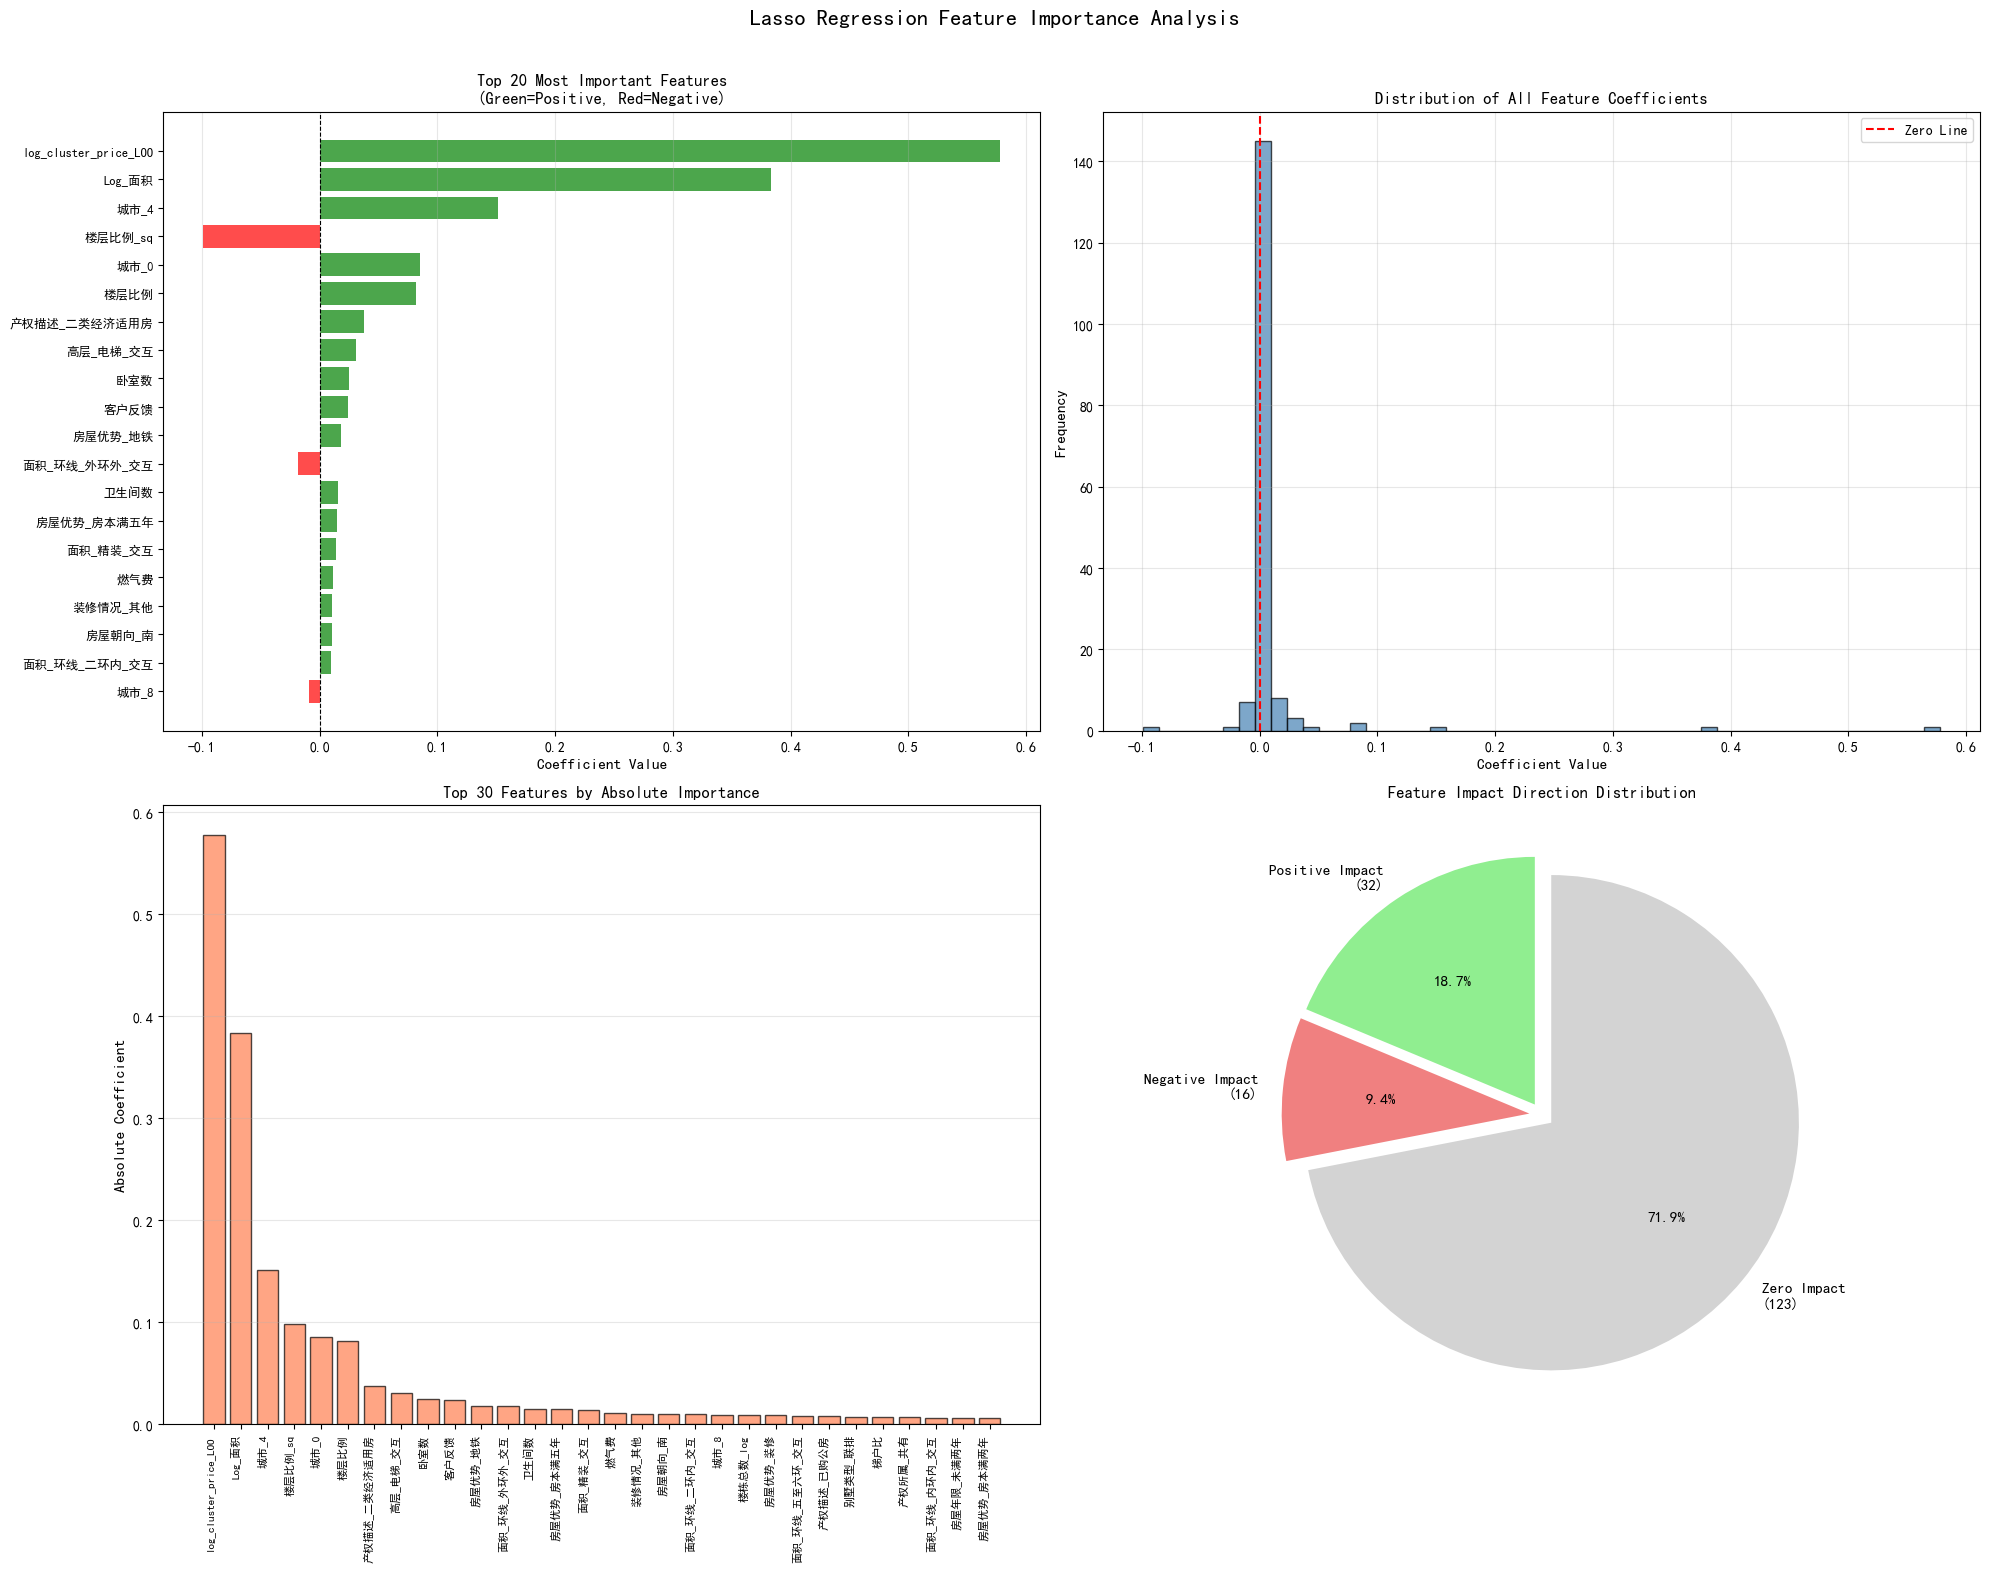


✅ Feature importance analysis complete!


In [54]:
# ==========================================================
# Feature Importance Visualization
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 支持中文显示
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle(f'{best_model_type} Regression Feature Importance Analysis', fontsize=16, fontweight='bold')

# 1. Top 20 Features by Absolute Coefficient (Horizontal Bar Chart)
top_20_features = feature_importance_df.head(20)
ax1 = axes[0, 0]
colors = ['green' if x > 0 else 'red' for x in top_20_features['Coefficient']]
ax1.barh(range(len(top_20_features)), top_20_features['Coefficient'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(top_20_features)))
ax1.set_yticklabels(top_20_features['Feature'], fontsize=9)
ax1.set_xlabel('Coefficient Value', fontsize=11, fontweight='bold')
ax1.set_title('Top 20 Most Important Features\n(Green=Positive, Red=Negative)', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# 2. Distribution of All Coefficients (Histogram)
ax2 = axes[0, 1]
ax2.hist(coefficients, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Coefficient Value', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.set_title('Distribution of All Feature Coefficients', fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Zero Line')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Top 30 Features by Absolute Value (Bar Chart)
top_30_abs = feature_importance_df.head(30)
ax3 = axes[1, 0]
ax3.bar(range(len(top_30_abs)), top_30_abs['Abs_Coefficient'], color='coral', alpha=0.7, edgecolor='black')
ax3.set_xticks(range(len(top_30_abs)))
ax3.set_xticklabels(top_30_abs['Feature'], rotation=90, ha='right', fontsize=8)
ax3.set_ylabel('Absolute Coefficient', fontsize=11, fontweight='bold')
ax3.set_title('Top 30 Features by Absolute Importance', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Positive vs Negative Impact Distribution (Pie Chart)
ax4 = axes[1, 1]
positive_count = (coefficients > 0).sum()
negative_count = (coefficients < 0).sum()
zero_count = (coefficients == 0).sum()

labels = [f'Positive Impact\n({positive_count})', 
          f'Negative Impact\n({negative_count})']
sizes = [positive_count, negative_count]
colors_pie = ['lightgreen', 'lightcoral']
explode = (0.05, 0.05)

if zero_count > 0:
    labels.append(f'Zero Impact\n({zero_count})')
    sizes.append(zero_count)
    colors_pie.append('lightgray')
    explode = (0.05, 0.05, 0.05)

ax4.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', 
        startangle=90, explode=explode, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax4.set_title('Feature Impact Direction Distribution', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
viz_filename = f'feature_importance_{best_model_type.lower()}_visualization.png'
plt.savefig(viz_filename, dpi=300, bbox_inches='tight')
print(f"\n📊 Visualization saved to: {viz_filename}")
plt.show()

print("\n✅ Feature importance analysis complete!")


In [55]:
submission

,ID,Price
0,1000000,1.963741e+07
1,1000001,3.422952e+06
2,1000002,4.099723e+06
3,1000003,2.600579e+06
4,1000004,6.626901e+06
...,...,...
34012,1034012,2.841022e+06
34013,1034013,4.993640e+05
34014,1034014,2.049961e+06
34015,1034015,1.996741e+06


In [56]:
submission.to_csv("C:/Users\lenovo\Desktop/price_1029")

In [56]:
submission = pd.read_csv("C:/Users\lenovo\Desktop/price_1028")

In [73]:
rent = pd.read_csv("C:/Users\lenovo\Desktop/rent_1029")

In [74]:
submission.head()

,ID,Price
0,1000000,1.963741e+07
1,1000001,3.422952e+06
2,1000002,4.099723e+06
3,1000003,2.600579e+06
4,1000004,6.626901e+06


In [75]:
rent = rent[['ID','Price']]

In [76]:
submission = submission[['ID','Price']]

In [77]:
sub = pd.concat([submission,rent])

In [78]:
rent.head()

,ID,Price
0,2000000,1.731684e+05
1,2000001,4.510726e+05
2,2000002,3.756047e+05
3,2000003,1.427849e+06
4,2000004,1.053070e+06


In [79]:
sub.head()

,ID,Price
0,1000000,1.963741e+07
1,1000001,3.422952e+06
2,1000002,4.099723e+06
3,1000003,2.600579e+06
4,1000004,6.626901e+06


In [81]:
sub.to_csv("C:/Users\lenovo\Desktop/submission_1031_context.csv", index = False)

In [179]:
# 特征标准化
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)

print(f"特征标准化完成:")
print(f"  训练集: {X_tr_scaled.shape}")
print(f"  验证集: {X_val_scaled.shape}")
print(f"\n✓ 数据预处理完成")


特征标准化完成:
  训练集: (74678, 169)
  验证集: (19780, 169)

✓ 数据预处理完成
